# FL16Y spectral fitting

In [60]:
%reset -f
%run pylib/tools dark
from pathlib import Path
from importlib import reload
from astropy.coordinates import SkyCoord
from utilities.ipynb_docgen import show, show_date
from like3 import pixel_table as pixel_table_mod; reload(pixel_table_mod)
PixelTable = pixel_table_mod.PixelTable
from like3 import sourcelist as sourcelist_mod; reload(sourcelist_mod)
SourceModel = sourcelist_mod.SourceModel
from like3 import bands as bands_mod; reload(bands_mod)
from like3 import likelihood as likelihood_mod; reload(likelihood_mod)
Likelihood = likelihood_mod.Likelihood
BandList = bands_mod.BandList
BandModel = bands_mod.BandModel
show_date()
pixtab = PixelTable('files/kerr/toby_v4')
pixtab.attach_exposure_from_fits('files/kerr/toby_v4_exposure.fits');


<h5 style="text-align:right; margin-right:15px"> 2026-04-05 07:15</h5>

Loaded pixel table from "files/kerr/toby_v4.npz":
            42 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,875 pixels
            


## Build a SourceModel From a Fermi catalog subset

Use the FL16Y catalog to create a compact ROI source model around a trial position. This supports the new `SourceModel.from_fermi_catalog(...)` entry point with spatial filtering, `query=`, and explicit `select=`.

In [61]:
roi_name, cone_size = 'Geminga', 1.0
roi_center = SkyCoord.from_name(roi_name)
roi_sources = SourceModel.from_fermi_catalog('uw1617',

    skydir=roi_center,
    cone_size=cone_size,
    query='significance >= 25',
)

selected_name = roi_sources.source_names[0]

show(
    f'''Loaded {len(roi_sources)} catalog sources within {cone_size} deg of {roi_center.to_string("decimal", precision=3)}.
First selected source: {selected_name}'''
)

Loaded Fermi 4FGL gll_pscP305uw1617_v4_assoc_v9r1_classes.fits: 7221 entries


Loaded 1 catalog sources within 1.0 deg of 98.476 17.770.
First selected source: PSRJ0633+1746

## Build a BandList using a pixel table

In [62]:
bl = bandlist = BandList.from_pixel_table(roi_sources, pixtab)

first_pixel_band = next(iter(pixtab.values()))
saved_sparse_exposure = getattr(first_pixel_band, 'pixel_exposure', None)
if saved_sparse_exposure is None:
    raise ValueError('Loaded PixelTable does not contain saved sparse pixel exposure')

probe_pix = np.asarray(first_pixel_band.pix[: min(3, len(first_pixel_band.pix))], dtype=int)
saved_probe = np.asarray(saved_sparse_exposure[: probe_pix.size], dtype=float)
bandlist_probe = bandlist[0].exposure_map(probe_pix)
np.testing.assert_allclose(bandlist_probe, saved_probe)

show(
    f'''Constructed BandList for {roi_sources.source_names[0]} from PixelTable {pixtab.name}''')
show({
    "Bands": len(bandlist),
    "First band": str(bandlist[0]),
    "Exposure source": "saved sparse pixel exposure",
    "Checked pixels": probe_pix.tolist(),
    "Saved exposure sample": saved_probe.tolist()
})


bandlist[:3]

Constructed BandList for PSRJ0633+1746 from PixelTable toby_v4

{'Bands': 42,
 'First band': 'Band( PSF0, 1.33 GeV, nside 64)',
 'Exposure source': 'saved sparse pixel exposure',
 'Checked pixels': [24224, 23968, 23967],
 'Saved exposure sample': [247922515968.0, 250032013312.0, 246993068032.00003]}

[Band( PSF0, 1.33 GeV, nside 64),
 Band( PSF0, 2.37 GeV, nside 64),
 Band( PSF0, 4.22 GeV, nside 128)]

## Study of band Band( PSF2, 1.33 GeV, nside 128)

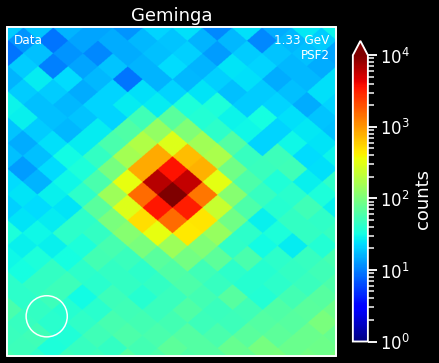

In [63]:
b = bandlist[2,4]
show(f"""## Study of band {b}""")

b.plot_pixel_map(roi_center, log=True, vmin=1, vmax=1e4, title=roi_name, axes_visible=False)

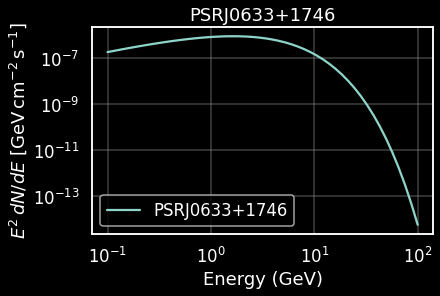

In [64]:
bl.sed_plot();

In [65]:
def pixel_map(self, data=None, center=roi_center,log=True, vmin=None, vmax=None,title=roi_name, label=None):
    pixid = self.data[0] # all the pixel ids with nonzero counts in this band
    if data is None:
        if label is None:
            label = 'Data'
            data_tuple = (self.data)
        else:
            if label.lower=='diffuse':
                data_tuple = (pixid,self.diffuse)
            elif label.lower()=='full model':
                data_tuple = (pixid,self.diffuse+self.pixel_counts(pixid)[1])
            elif label.lower()=='source model':
                data_tuple = self.pixel_counts(pixid)
            else:
                raise ValueError(\
                    """If label is provided, it must be 'diffuse' to use the diffuse contribution as data
                    or 'model_total' to use the sum of the diffuse contribution and the source counts as data""")    

    elif type(data) is tuple and len(data) == 2:
        data_tuple = data
    elif type(data) is np.ndarray and len(data)==pixid.size:
        data_tuple = (pixid, data) 
    else:
        raise TypeError("Expected data to be a tuple of length 2 or a numpy ndarray")
    b.plot_pixel_map(center, data=data_tuple,  log=log, vmin=vmin,vmax=vmax,
                      title=title,label=label, axes_visible=False)


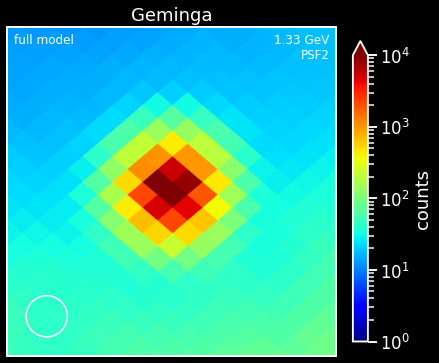

In [66]:
pixel_map(b, log=True, vmin=1, vmax=1e4, label='full model')

CPU times: user 1.36 s, sys: 22.8 ms, total: 1.38 s
Wall time: 1.44 s


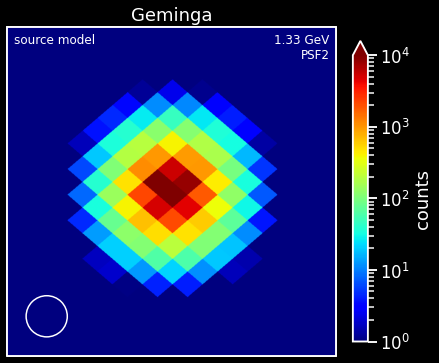

In [67]:
%time pixel_map(b, vmin=1, vmax=1e4, log=True, label='source model')

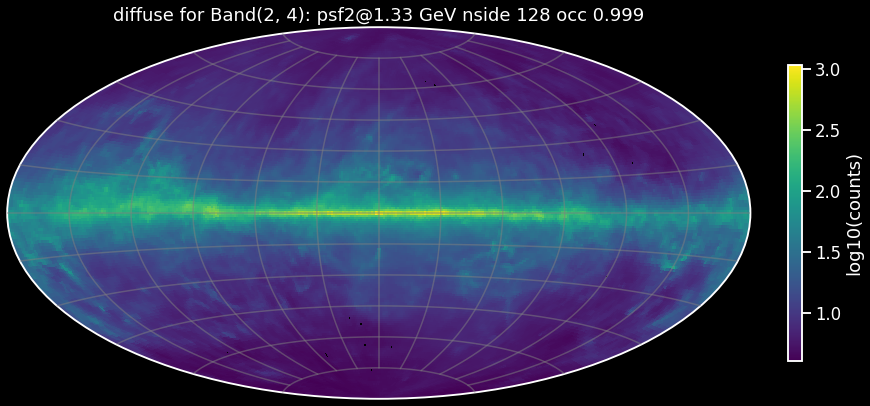

In [68]:
pixtab[2,4].ait_plot('diffuse');

## Apply Likelihood to a Band

`BandModel` is a thin adapter that wraps a `Band` instance and exposes the interface required by `likelihood.Likelihood`:
- `parameters` / `parsubset` — delegated to the underlying `SourceModel`
- `counts()` — source-model pixel counts plus the per-pixel diffuse contribution, evaluated on the data pixels
- `count_gradient()` — gradient of source counts w.r.t. free parameters, shape `(n_params, n_pixels)` (transpose of `Band.pixel_gradient`)


In [69]:
# --- Build model and data from band b ---
bm = BandModel(b)

show(f"""
**Active pixels**: {len(bm._pix)} of {len(b.data[0])} data pixels  
(restricted to those illuminated by pixel_counts())
""")


**Active pixels**: 45 of 196428 data pixels  
(restricted to those illuminated by pixel_counts())

In [70]:
print(reload(likelihood_mod))
Likelihood = likelihood_mod.Likelihood
L = Likelihood(bm, bm.data)

# Evaluate at current parameter values
x0 = bm.parameters.values.copy()
logl_val, grad_val = L._evaluate(x0)

show(f"""
**Likelihood at initial parameters**  
log-likelihood: `{logl_val:.4f}`  
gradient: `{np.array2string(grad_val, precision=4)}`
""")

# Verify shapes and finiteness
assert grad_val.shape == (len(x0),), f"Unexpected gradient shape {grad_val.shape}"
assert np.isfinite(logl_val), "log-likelihood is not finite"
assert np.all(np.isfinite(grad_val)), "gradient contains non-finite values"
show("All assertions passed.")

<module 'like3.likelihood' from '/mnt/c/Users/thbur/onedrive/work/pixel-table/like3/likelihood.py'>


**Likelihood at initial parameters**  
log-likelihood: `380837.8321`  
gradient: `[-94936.3873 -11011.0261]`

All assertions passed.

In [71]:
print(reload(likelihood_mod))
Likelihood = likelihood_mod.Likelihood
L = Likelihood(bm, bm.data)
L.select(1)
L.maximize()
show(L.fit_info)
L.summary()

<module 'like3.likelihood' from '/mnt/c/Users/thbur/onedrive/work/pixel-table/like3/likelihood.py'>


{'hess': array([[3617.75669324]]),
 'cov': array([[0.00027641]]),
 'sigs': array([0.01662571]),
 'corr': array([[1.]]),
 'grad': array([0.0073913]),
 'x_fit': array([-0.16935966]),
 'delta_loglike': 10958.99,
 'funcalls': 6,
 'ts_values': array([nan])}

Name                  index     value  error(%)  gradient        TS
PSRJ0633+1746_Index       1   -0.1694       9.8       0.0          


In [72]:
# Diffuse component at the Geminga pixel for each band
diffuse_at_geminga = []
for band in bandlist:
    pix = band.skycoord_to_healpix(roi_center)
    data_pix = band.data[0]
    idx = np.searchsorted(data_pix, pix)
    if idx < len(data_pix) and data_pix[idx] == pix and band.diffuse is not None:
        val = band.diffuse[idx]
    else:
        val = np.nan
    diffuse_at_geminga.append(val)
diffuse_at_geminga = np.array(diffuse_at_geminga)
print(diffuse_at_geminga)


[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan]


In [73]:
L.model.parameter_names[L.model.parameters.mask]

array(['PSRJ0633+1746_Index'], dtype='<U19')

In [74]:
def evaluate_ts(self):
    """Compute TS-like drops by forcing `_Norm` parameters to -20."""
    model = self.model
    logl = self.log_like
    x_fit = self.fit_info['x_fit'].copy()
    val_fit = -self(x_fit)[0]
    values = x_fit.copy()
    ts_array = np.full_like(values, np.nan)

    for k, name in enumerate(model.parameter_names):
        print(k,name)
        if name.endswith('_Norm'):
            values[k] = -20
            ts_array[k] = round(2*(val_fit - logl(values)),1)
            values[k] = x_fit[k]
            model.parameters.values = x_fit
    return ts_array
evaluate_ts(L)

0 PSRJ0633+1746_Norm
1 PSRJ0633+1746_Index


array([348663.9])

In [75]:
hess = L.fit_info['hess']
np.linalg.inv(hess)

array([[0.00027641]])

In [76]:
m = b.source_model[0].model;
# m[0] = 10**-9.789039
bm = BandModel(b)
L = Likelihood(bm, bm.data)
print(L.summary())
L.select(0)
x0 = bm.parameters.values.copy()
logl_val, grad_val = L._evaluate(x0)

show(f"""
**Likelihood at initial parameters**  
log-likelihood: `{logl_val:.4f}`  
gradient: `{np.array2string(grad_val, precision=4)}`
""")

Name                  index     value  error(%)
PSRJ0633+1746_Norm        0 2.935e-10       ***
             _Index       1   -0.1694       9.8
None


**Likelihood at initial parameters**  
log-likelihood: `391796.8215`  
gradient: `[0.0637]`

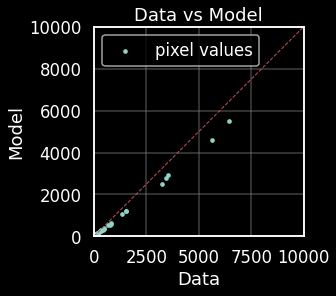

In [77]:

model, data = L.model.counts(), L.data
plt.figure(figsize=(8,4))
plt.scatter(data, model, s=10, label='pixel values')
plt.plot([0,10000],[0,10000], 'r--', lw=1)
plt.gca().set(ylim=(0,10000), aspect=1, 
              xlim=(0,10000))#, adjustable='box')
plt.xlabel('Data')
plt.ylabel('Model')
plt.title('Data vs Model')
plt.legend()
plt.show()

/tmp/ipykernel_2261/735983257.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


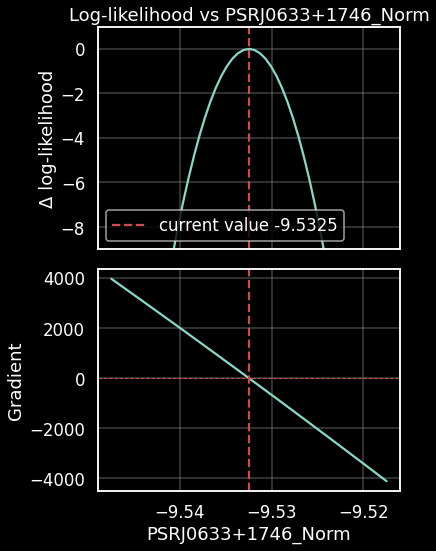

In [78]:
import matplotlib.pyplot as plt

x_scan = x0.copy()
par_name = bm.parameter_names[0]
par_values = np.linspace(x0[0] -0.015, x0[0] +0.015, 51)
logl_values = []
grad_values = []
for v in par_values:
    x_scan[0] = v
    logl, grad = L._evaluate(x_scan)
    logl_values.append(logl)
    grad_values.append(grad)
logl_values = np.array(logl_values)
grad_values = np.array(grad_values)

fig, (ax, ax2) = plt.subplots(nrows=2, figsize=(6, 8), sharex=True)
ax.plot(par_values, logl_values - logl_values.max())
ax.axvline(x0[0], color='r', linestyle='--', label=f'current value {x0[0]:.4f}')
ax.set_ylabel('Δ log-likelihood')
ax.set_title(f'Log-likelihood vs {par_name}')
ax.set(ylim=(-9,1))
ax.legend()

ax2.plot(par_values, grad_values)
ax2.axhline(0, color='r', linestyle='--', lw=1)
ax2.set_xlabel(par_name)
ax2.set_ylabel('Gradient')
ax2.axvline(x0[0], color='r', linestyle='--', label=f'current value {x0[0]:.4f}')

plt.tight_layout()
plt.show()


# restore original parameter values
bm.parameters.values = x0


In [79]:
L.maximize()
show(L.fit_info)
show(L.summary())

{'hess': array([[268936.2905396]]),
 'cov': array([[3.71835277e-06]]),
 'sigs': array([0.0019283]),
 'corr': array([[1.]]),
 'grad': array([0.00153254]),
 'x_fit': array([-9.53245947]),
 'delta_loglike': 0.0,
 'funcalls': 3,
 'ts_values': array([438732.4])}

Name                  index     value  error(%)  gradient        TS
PSRJ0633+1746_Norm        0 2.935e-10       0.4       0.0    438732


None

In [80]:
src_pix, src_counts = b.pixel_counts(bm._pix)
diffuse = bm._diffuse if hasattr(bm._diffuse, '__len__') else np.full(len(bm._pix), float(bm._diffuse))
print(f'x0              : {x0}')
print(f'Active pixels   : {len(bm._pix)}')
print(f'Total data      : {bm.data.sum():.1f}')
print(f'Total diffuse   : {diffuse.sum():.2f}')
print(f'Total src counts: {src_counts.sum():.4f}  (at x0)')
print(f'Total model     : {(src_counts + diffuse).sum():.2f}')
logl_at_x0, grad_at_x0 = L._evaluate(x0)
print(f'LogL at x0      : {logl_at_x0:.4f}')
print(f'Gradient at x0  : {grad_at_x0}')


x0              : [-9.5324597]
Active pixels   : 45
Total data      : 53389.0
Total diffuse   : 1194.44
Total src counts: 51899.7470  (at x0)
Total model     : 53094.18
LogL at x0      : 391796.8215
Gradient at x0  : [0.06372737]


In [81]:
1.625e-10  /  2.935e-10

0.5536626916524702